# Stage 09: Feature Engineering

This notebook creates leakage-aware predictors and a separate future five-trading-day realized-volatility target for the S&P 500 volatility project.

## Inputs Assessment

- The Stage 09 lecture is useful for temporal, rolling, calendar, interaction, and transformation features.
- The supplied `env.example` is a useful configuration pattern, but its dummy API key and generic data path are not copied into the project. This homework uses a project-specific `.env.example`.
- The supplied `starter_data.csv` is a generic category/value/date exercise and is not used because it contains no market prices, returns, volume, or volatility fields.

In [1]:
from datetime import datetime, timezone
import json
import os
from pathlib import Path
import sys

os.environ.setdefault('MPLCONFIGDIR', str(Path('/tmp') / 'matplotlib'))
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

REPO_ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / 'homework' / 'homework09').exists()
)
HOMEWORK_DIR = REPO_ROOT / 'homework' / 'homework09'
load_dotenv(HOMEWORK_DIR / '.env')
PROCESSED_DIR = HOMEWORK_DIR / os.environ.get('DATA_DIR_PROCESSED', 'data/processed')
REPORTS_DIR = HOMEWORK_DIR / os.environ.get('REPORTS_DIR', 'reports')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(HOMEWORK_DIR / 'src'))
from feature_utils import create_time_series_features, validate_model_ready_data

RUN_TIMESTAMP = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')

## Load the Cleaned Time Series
The Stage 06 dataset contains validated price, volume, and return data. Features will be calculated chronologically.

In [2]:
stage06_processed_dir = REPO_ROOT / 'homework' / 'homework06' / 'data' / 'processed'
source_files = sorted(stage06_processed_dir.glob('sp500_prices_cleaned_*.parquet'))
if not source_files:
    raise FileNotFoundError('Run the Stage 06 notebook first so cleaned data are available.')

source_path = source_files[-1]
cleaned_prices = pd.read_parquet(source_path).sort_values('date').reset_index(drop=True)
cleaned_prices[['date', 'close', 'volume', 'daily_return']].head()

/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.l1dcachesize'. Detail: [errno 1] Operation not permitted
/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.l2cachesize'. Detail: [errno 1] Operation not permitted
/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.l3cachesize'. Detail: [errno 1] Operation not permitted
/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.optional.neon'. Detail: [errno 1] Operation not permitted


,date,close,volume,daily_return
0,2025-01-02,5868.55,3621680000,0.0
1,2025-01-03,5942.47,3667340000,0.012596
2,2025-01-06,5975.38,4940120000,0.005538
3,2025-01-07,5909.03,4517330000,-0.011104
4,2025-01-08,5881.7,4441740000,-0.004625


## Create Leakage-Aware Features and Target
All lagged and rolling return features are shifted before they are calculated. The future volatility value is added only as the target for a later supervised-learning stage.

In [3]:
engineered_data, feature_columns, feature_registry = create_time_series_features(cleaned_prices)
model_ready_data = engineered_data.dropna(subset=feature_columns + ['future_5d_realized_volatility']).copy()
validation_results = validate_model_ready_data(model_ready_data, feature_columns)
print('Feature columns:', feature_columns)
print('Full rows:', len(engineered_data), '| Model-ready rows:', len(model_ready_data))
print('Validation:', validation_results)
model_ready_data[['date'] + feature_columns + ['future_5d_realized_volatility']].head()

Feature columns: ['return_lag_1', 'return_lag_3', 'return_rolling_mean_3', 'return_rolling_volatility_5', 'volume_pct_change_1', 'volume_relative_to_5d', 'log_volume', 'close_relative_to_3d', 'return_lag_1_x_volume_change_1', 'weekday_Friday', 'weekday_Monday', 'weekday_Thursday', 'weekday_Tuesday', 'weekday_Wednesday']
Full rows: 19 | Model-ready rows: 8
Validation: {'features_present': True, 'no_missing_features_or_target': True, 'finite_numeric_features': True, 'dates_sorted': True, 'nonnegative_target': True}


,date,return_lag_1,return_lag_3,return_rolling_mean_3,return_rolling_volatility_5,volume_pct_change_1,volume_relative_to_5d,log_volume,close_relative_to_3d,return_lag_1_x_volume_change_1,weekday_Friday,weekday_Monday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,future_5d_realized_volatility
6,2025-01-13,-0.009293,-0.011104,-0.008341,0.009065,-0.069599,0.990481,22.209677,-0.006193,0.000647,0,1,0,0,0,0.007171
7,2025-01-14,0.001575,-0.004625,-0.004114,0.006326,-0.063087,0.897673,22.144512,-0.000925,-0.000099,0,0,0,1,0,0.006579
8,2025-01-15,0.001146,-0.009293,-0.002191,0.005204,0.097118,1.020129,22.237199,0.019625,0.000111,0,0,0,0,1,0.004223
9,2025-01-16,0.018313,0.001575,0.007011,0.009346,-0.023671,0.994765,22.213243,0.010379,-0.000433,0,0,1,0,0,0.004497
10,2025-01-17,-0.002113,0.001146,0.005782,0.009071,-0.015814,0.979243,22.197303,0.014654,0.000033,1,0,0,0,0,0.005532


## Visual Check
The plot compares the current daily return with its past-only rolling volatility and shows the future-volatility target separately. It is a construction check, not model performance.

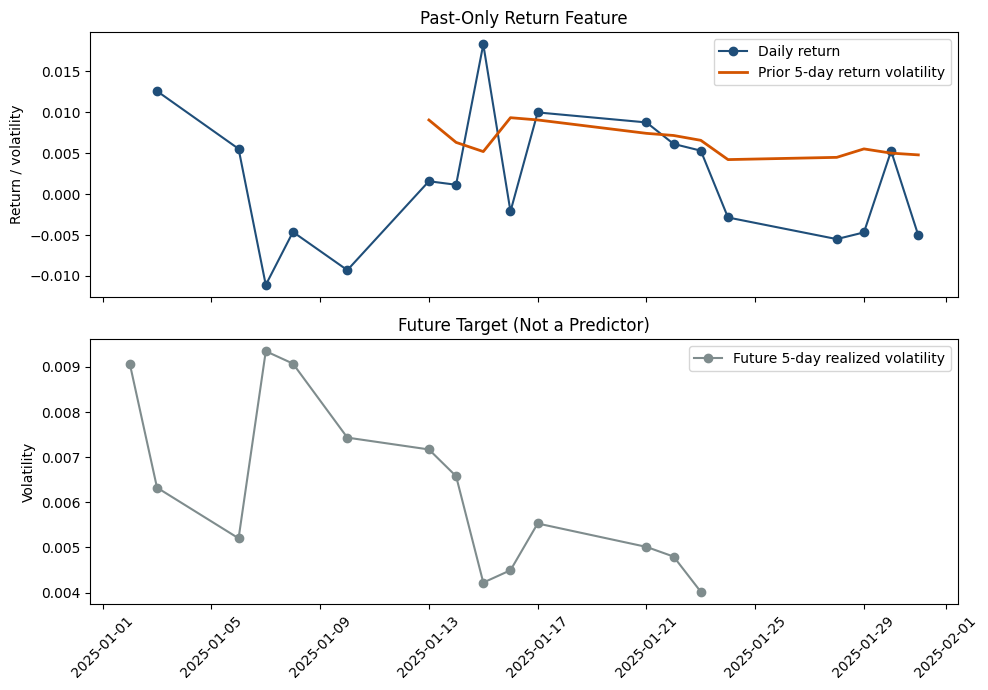

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(engineered_data['date'], engineered_data['daily_return'], marker='o', label='Daily return', color='#1f4e79')
axes[0].plot(engineered_data['date'], engineered_data['return_rolling_volatility_5'], linewidth=2, label='Prior 5-day return volatility', color='#d35400')
axes[0].set_title('Past-Only Return Feature')
axes[0].set_ylabel('Return / volatility')
axes[0].legend()
axes[1].plot(engineered_data['date'], engineered_data['future_5d_realized_volatility'], marker='o', label='Future 5-day realized volatility', color='#7f8c8d')
axes[1].set_title('Future Target (Not a Predictor)')
axes[1].set_ylabel('Volatility')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
plt.tight_layout()
feature_plot_path = REPORTS_DIR / f'feature_target_overview_{RUN_TIMESTAMP}.png'
plt.savefig(feature_plot_path, dpi=150)
plt.show()

## Save Feature Tables and Registry
The full table preserves rows with expected feature/target gaps at the start and end of the time series. The model-ready table excludes only rows lacking a selected predictor or target.

In [5]:
full_parquet_path = PROCESSED_DIR / f'engineered_features_full_{RUN_TIMESTAMP}.parquet'
model_ready_csv_path = PROCESSED_DIR / f'model_ready_features_{RUN_TIMESTAMP}.csv'
model_ready_parquet_path = PROCESSED_DIR / f'model_ready_features_{RUN_TIMESTAMP}.parquet'
registry_path = PROCESSED_DIR / f'feature_registry_{RUN_TIMESTAMP}.json'
metadata_path = PROCESSED_DIR / f'feature_engineering_metadata_{RUN_TIMESTAMP}.json'

engineered_data.to_parquet(full_parquet_path, index=False)
model_ready_data.to_csv(model_ready_csv_path, index=False)
model_ready_data.to_parquet(model_ready_parquet_path, index=False)
registry_path.write_text(json.dumps(feature_registry, indent=2), encoding='utf-8')
metadata = {
    'source_file': str(source_path.relative_to(REPO_ROOT)),
    'full_rows': int(len(engineered_data)),
    'model_ready_rows': int(len(model_ready_data)),
    'feature_columns': feature_columns,
    'target_column': 'future_5d_realized_volatility',
    'validation_results': validation_results,
    'outputs': {
        'full_parquet': str(full_parquet_path.relative_to(REPO_ROOT)),
        'model_ready_csv': str(model_ready_csv_path.relative_to(REPO_ROOT)),
        'model_ready_parquet': str(model_ready_parquet_path.relative_to(REPO_ROOT)),
        'registry': str(registry_path.relative_to(REPO_ROOT)),
        'feature_plot': str(feature_plot_path.relative_to(REPO_ROOT)),
    },
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

reloaded_model_ready = pd.read_parquet(model_ready_parquet_path)
assert reloaded_model_ready.shape == model_ready_data.shape
assert validate_model_ready_data(reloaded_model_ready, feature_columns) == validation_results
print('Saved feature outputs:', full_parquet_path.name, model_ready_csv_path.name, registry_path.name)

Saved feature outputs: engineered_features_full_20260820-051747.parquet model_ready_features_20260820-051747.csv feature_registry_20260820-051747.json


## Modeling Implications

The new features create plausible inputs for forecasting future volatility, but the small model-ready sample is not sufficient for training or evaluating a reliable model. In the next stage, longer history should be collected before time-based train/test splitting and model fitting.